# Variable-neighbourhood LNS model with time as a feature

Train one pooled quality model across neighbourhoods 4, 8, 16 and 32 and across all eight policy horizons. Both neighbourhood size and LNS horizon are model features, so each fold trains one model rather than one model per horizon. MovingAI and POGEMA both use shuffled, instance-disjoint five-fold predictions. Evaluation reports per-neighbourhood regression metrics and neighbourhood-selection accuracy and regret.

In [12]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

from mapf_anytime.features import LACAM_FEATURES, STATIC_FEATURES
from mapf_anytime.policies.layered_v1 import LNS_PARAMETERS

ROOT = Path.cwd().resolve()
while not (ROOT / "datasets").is_dir():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("Run this notebook from inside the repository")
    ROOT = ROOT.parent

MOVINGAI_DATASET = ROOT / "datasets/movingai_final.csv"
POGEMA_DATASET = ROOT / "datasets/pogema_final.csv"
NEIGHBOURHOODS = (4, 8, 16, 32)
HORIZONS = (1, 2, 5, 10, 20, 30, 50, 100)
TIME_FEATURE = "lns_horizon_seconds"
BASE_FEATURES = (*STATIC_FEATURES, *LACAM_FEATURES, "lns_neighborhood_size")
FEATURES = (*BASE_FEATURES, TIME_FEATURE)
FOLDS = 5
SEED = 42
JOBS = 8

In [13]:
def load_dataset(path):
    data = pd.read_csv(path)
    if "repetition" in data:
        raise ValueError("Use averaged dataset.csv, not dataset_raw.csv")
    if "lacam_seed" not in data:
        data["lacam_seed"] = 0

    data = data[data.lns_neighborhood_size.isin(NEIGHBOURHOODS)].copy()
    parsed = data.lns_best_sod_by_second.map(json.loads)
    valid = parsed.map(len).gt(max(HORIZONS))
    data, parsed = data.loc[valid].copy(), parsed.loc[valid]

    targets = np.vstack([
        np.maximum(0.0, row.lacam_initial_sod - np.minimum.accumulate(curve))
        / row.lower_bound_soc
        for row, curve in zip(data.itertuples(), parsed)
    ])
    for second in HORIZONS:
        data[f"target_{second}"] = targets[:, second]

    target_columns = [f"target_{second}" for second in HORIZONS]
    required = [*BASE_FEATURES, *target_columns]
    data[required] = data[required].replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=required)
    data["lacam_seed"] = data.lacam_seed.astype(int)
    data["lns_neighborhood_size"] = data.lns_neighborhood_size.astype(int)

    counts = data.groupby(["instance_id", "lacam_seed"]).lns_neighborhood_size.nunique()
    complete = set(counts[counts.eq(len(NEIGHBOURHOODS))].index)
    keys = list(zip(data.instance_id, data.lacam_seed))
    return data.loc[[key in complete for key in keys]].reset_index(drop=True)


datasets = {
    "MovingAI": load_dataset(MOVINGAI_DATASET),
    "POGEMA-Maze": load_dataset(POGEMA_DATASET),
}

display(pd.DataFrame({
    name: {
        "base instances": data.instance_id.nunique(),
        "seed runs": data[["instance_id", "lacam_seed"]].drop_duplicates().shape[0],
        "maps": data.map_name.nunique(),
        "rows": len(data),
    }
    for name, data in datasets.items()
}).T)

,base instances,seed runs,maps,rows
MovingAI,4432,17488,33,69952
POGEMA-Maze,4677,18377,4677,73508


In [14]:
def folds(data):
    instances = data[["instance_id", "map_name"]].drop_duplicates("instance_id")
    split = KFold(FOLDS, shuffle=True, random_state=SEED).split(instances)
    for train, test in split:
        yield set(instances.iloc[train].instance_id), set(instances.iloc[test].instance_id)


def design(frame):
    rows = frame.loc[
        frame.index.repeat(len(HORIZONS)), list(BASE_FEATURES)
    ].reset_index(drop=True)
    rows[TIME_FEATURE] = np.tile(HORIZONS, len(frame))
    return rows[list(FEATURES)]


def fit_model(training, seed):
    estimator = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=JOBS,
        random_state=seed,
        **LNS_PARAMETERS,
    )
    targets = training[[f"target_{second}" for second in HORIZONS]].to_numpy().reshape(-1)
    estimator.fit(design(training), np.log1p(targets))
    return estimator


def predict_model(estimator, evaluation):
    prediction = np.expm1(estimator.predict(design(evaluation)))
    return np.maximum(0.0, prediction.reshape(len(evaluation), len(HORIZONS)))


def evaluate(data):
    predictions = np.full((len(data), len(HORIZONS)), np.nan)
    fold_metrics = []
    models = []

    for fold, (train_ids, test_ids) in enumerate(folds(data)):
        train = data.instance_id.isin(train_ids)
        test = data.instance_id.isin(test_ids)
        assert train_ids.isdisjoint(test_ids)
        estimator = fit_model(data.loc[train], SEED + fold)
        predictions[test] = predict_model(estimator, data.loc[test])
        models.append(estimator)

        for column, second in enumerate(HORIZONS):
            target = f"target_{second}"
            for neighbourhood in NEIGHBOURHOODS:
                neighbourhood_test = test & data.lns_neighborhood_size.eq(neighbourhood)
                actual = data.loc[neighbourhood_test, target].to_numpy()
                prediction = predictions[neighbourhood_test, column]
                mae = mean_absolute_error(actual, prediction)
                fold_metrics.append({
                    "neighbourhood": neighbourhood,
                    "horizon (s)": second,
                    "fold": fold + 1,
                    "R²": r2_score(actual, prediction),
                    "MAE": mae,
                    "MAE / mean": mae / actual.mean() if actual.mean() else np.nan,
                })

    if np.isnan(predictions).any():
        raise RuntimeError("Some observations did not receive an OOF prediction")
    result = data.copy()
    for column, second in enumerate(HORIZONS):
        result[f"prediction_{second}"] = predictions[:, column]
    return result, pd.DataFrame(fold_metrics), models


evaluated, fitted_models, metric_parts = {}, {}, []
for label, data in datasets.items():
    evaluated[label], fold_metrics, fitted_models[label] = evaluate(data)
    fold_metrics.insert(0, "model", label)
    metric_parts.append(fold_metrics)

metrics = pd.concat(metric_parts, ignore_index=True)
mean_metrics = metrics.groupby(
    ["model", "neighbourhood", "horizon (s)"], as_index=False
)[["R²", "MAE", "MAE / mean"]].mean()
display(mean_metrics.round(4))

,model,neighbourhood,horizon (s),R²,MAE,MAE / mean
0,MovingAI,4,1,0.9092,0.0058,0.2076
1,MovingAI,4,2,0.9206,0.0066,0.1876
2,MovingAI,4,5,0.9330,0.0077,0.1665
3,MovingAI,4,10,0.9477,0.0083,0.1484
4,MovingAI,4,20,0.9536,0.0094,0.1405
...,...,...,...,...,...,...
59,POGEMA-Maze,32,10,0.8679,0.0070,0.2368
60,POGEMA-Maze,32,20,0.8692,0.0078,0.2210
61,POGEMA-Maze,32,30,0.8730,0.0082,0.2094
62,POGEMA-Maze,32,50,0.8832,0.0088,0.1965


In [15]:
def ranking_metrics(data):
    rows = []
    for second in HORIZONS:
        actual = data.pivot(
            index=["instance_id", "lacam_seed"],
            columns="lns_neighborhood_size",
            values=f"target_{second}",
        )[list(NEIGHBOURHOODS)]
        predicted = data.pivot(
            index=["instance_id", "lacam_seed"],
            columns="lns_neighborhood_size",
            values=f"prediction_{second}",
        )[list(NEIGHBOURHOODS)]

        actual_order = np.argsort(-actual.to_numpy(), axis=1, kind="stable")
        predicted_order = np.argsort(-predicted.to_numpy(), axis=1, kind="stable")
        chosen = predicted_order[:, 0]
        best = actual.to_numpy().max(axis=1)
        selected = actual.to_numpy()[np.arange(len(actual)), chosen]
        baseline = actual[4].to_numpy()

        for k in range(1, len(NEIGHBOURHOODS) + 1):
            overlap = [
                len(set(truth[:k]) & set(guess[:k])) / k
                for truth, guess in zip(actual_order, predicted_order)
            ]
            rows.append({
                "horizon (s)": second,
                "k": k,
                "top-k precision": np.mean(overlap),
                "exact-best accuracy": np.mean(np.isclose(selected, best)),
                "model regret": np.mean(best - selected),
                "always n=4 regret": np.mean(best - baseline),
            })
    return pd.DataFrame(rows)


ranking_parts = []
for label, data in evaluated.items():
    result = ranking_metrics(data)
    result.insert(0, "model", label)
    ranking_parts.append(result)
rankings = pd.concat(ranking_parts, ignore_index=True)

display(
    rankings[rankings.k.eq(1)]
    [["model", "horizon (s)", "exact-best accuracy", "model regret", "always n=4 regret"]]
    .round(4)
)

,model,horizon (s),exact-best accuracy,model regret,always n=4 regret
0,MovingAI,1,0.8313,0.0007,0.0010
4,MovingAI,2,0.8193,0.0008,0.0013
8,MovingAI,5,0.7736,0.0009,0.0017
12,MovingAI,10,0.7529,0.0008,0.0018
16,MovingAI,20,0.7112,0.0009,0.0022
20,MovingAI,30,0.6925,0.0010,0.0024
24,MovingAI,50,0.6741,0.0012,0.0028
28,MovingAI,100,0.6548,0.0014,0.0034
32,POGEMA-Maze,1,0.8570,0.0008,0.0012
36,POGEMA-Maze,2,0.8219,0.0008,0.0014


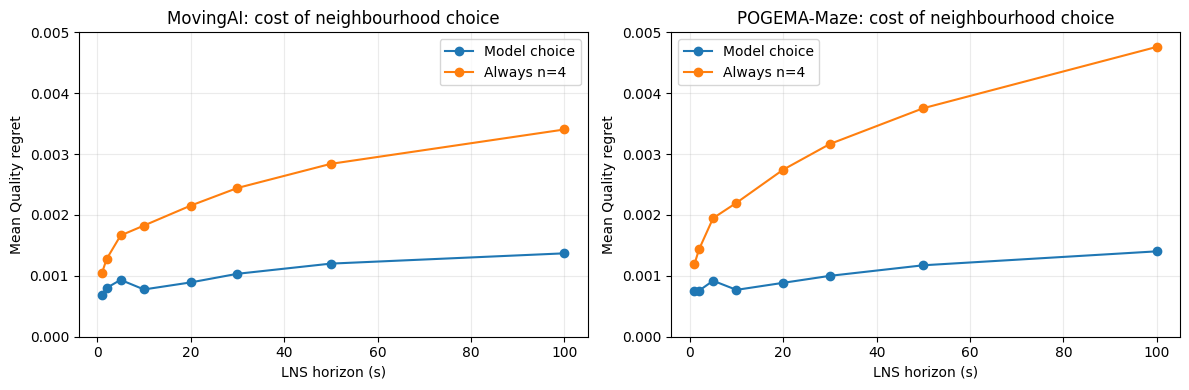

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, (model_name, values) in zip(axes, rankings.groupby("model", sort=False)):
    regret = values[values.k.eq(1)]
    axis.plot(
        regret["horizon (s)"], regret["model regret"],
        marker="o", label="Model choice",
    )
    axis.plot(
        regret["horizon (s)"], regret["always n=4 regret"],
        marker="o", label="Always n=4",
    )
    axis.set(
        title=f"{model_name}: cost of neighbourhood choice",
        xlabel="LNS horizon (s)",
        ylabel="Mean Quality regret",
        ylim=(0, 0.005),
    )
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()